# rliable comparison — interactive

Everything the `rliable_compare.py` CLI does, but broken into cells so you can
tweak one knob and re-run one figure instead of re-running the whole script.

**How to use it:** run cells 1–4 once (loading and bootstrapping is the slow
part), then live in section 5. Each figure cell is independent — edit a colour,
a size, a label, re-run that one cell.

If you change anything in `rliable_compare.py` itself, restart the kernel (or
run `importlib.reload(rc)`) to pick it up.

## 1. Setup

In [1]:
import sys, importlib
from pathlib import Path

# folder containing rliable_compare.py — "." if the notebook sits beside it
SCRIPT_DIR = Path(".").resolve()
sys.path.insert(0, str(SCRIPT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rliable import library as rly

import compare as rc
importlib.reload(rc)

# rc sets the Agg backend on import; switch back so figures show up inline
%matplotlib inline

print("loaded from", rc.__file__)

loaded from /home/rudra/Documents/rep_lr/compare.py


## 2. Configure

Every option here matches a CLI flag of the same name (`fig_width` is
`--fig-width`, and so on), so anything you settle on in the notebook transfers
straight to the command line.

In [5]:
args = rc.default_args(
    # ---- where the logs are ------------------------------------------------
    logs_dir="logs_fresh",      # root containing <Env>/<algo>/seed-*/progress.csv
    # envs=["all"],               # ["all"] or e.g. ["BallInCup", "CheetahRun"]
    envs = ["BallInCup", "CartpoleBalanceSparse", "CartpoleSwingup", "CartpoleSwingupSparse", "CheetahRun", "FingerSpin", "FingerTurnEasy", "FingerTurnHard","FishSwim", "HopperHop", "HopperStand", "ReacherEasy", "ReacherHard", "WalkerRun", "WalkerStand", "WalkerWalk"],

    algos=["dhpg_fix2", "mico_2", "algo_aug", "algo3"],   # ALSO sets display order: first = leftmost
                                    # in the legend, top row in the tables

    # ---- what to plot ------------------------------------------------------
    metric_col="Eval/Return",   # any column in progress.csv
    step_col="Train/Steps",
    max_score=1000.0,           # normaliser; 1000 = DMC max return
    final_window=1,             # average the last N evals as the final score
    smooth=1,                   # rolling-mean window for CURVES only (1 = off);
                                # never affects reported numbers
    drop_leading_zeros=False,   # strip placeholder zero rows before first eval
    max_steps=None,             # truncate all runs at this step count
    curve_points=101,           # resolution of the shared step grid

    # ---- statistics --------------------------------------------------------
    reps=20000,                  # bootstrap resamples; 2000 is fine while
                                # iterating, raise to 20000 for the final figures
    seed=0,

    # ---- naming and colour -------------------------------------------------
    labels={"algo3": "Ours", "dhpg_fix2": "DHPG", "mico_2":"MICO", "algo_aug":"Ours (+ Aug)"},
    color_overrides={"algo3": "#c0392b"},   # anything unset falls back to
                                            # rc.PALETTE in `algos` order

    # ---- figure geometry ---------------------------------------------------
    fig_width=5.5,              # text width in inches (5.5 for ICLR)
    font="sans",                # "sans" or "serif"
    font_size=11.0,
    grid_cols=4,                # panels per row in the per-environment grid
    panel_width=None,           # None = split fig_width across the columns
    panel_height=1.45,
    panel_pad=None,             # gap between panels, inches (None = ~0.04)
    margin_right=0.55,          # balances the y-label space on the left
    margin_left=0.0,

    # ---- output ------------------------------------------------------------
    out_dir="rliable_out",
    formats=["pdf"],
    dpi=400,
)

rc.setup_style(args)   # re-run this cell after changing font/size/colours
args

Namespace(logs_dir='logs_fresh', envs=['BallInCup', 'CartpoleBalanceSparse', 'CartpoleSwingup', 'CartpoleSwingupSparse', 'CheetahRun', 'FingerSpin', 'FingerTurnEasy', 'FingerTurnHard', 'FishSwim', 'HopperHop', 'HopperStand', 'ReacherEasy', 'ReacherHard', 'WalkerRun', 'WalkerStand', 'WalkerWalk'], algos=['dhpg_fix2', 'mico_2', 'algo_aug', 'algo3'], step_col='Train/Steps', metric_col='Eval/Return', max_score=1000.0, final_window=1, max_steps=None, curve_points=101, smooth=1, drop_leading_zeros=False, reps=20000, seed=0, out_dir='rliable_out', label_pairs=[], color_pairs=[], fig_width=5.5, font='sans', font_size=11.0, grid_cols=4, panel_width=None, panel_height=1.45, panel_pad=None, margin_right=0.55, margin_left=0.0, formats=['pdf'], dpi=400, labels={'algo3': 'Ours', 'dhpg_fix2': 'DHPG', 'mico_2': 'MICO', 'algo_aug': 'Ours (+ Aug)'}, color_overrides={'algo3': '#c0392b'})

### Which columns are available?

Handy when you move on from `Eval/Return` to one of the representation metrics.

In [6]:
probe = next(Path(args.logs_dir).glob("*/*/seed-*/progress.csv"))
print(probe)
list(pd.read_csv(probe, nrows=1).columns)

logs_fresh/CartpoleBalanceSparse/algo4/seed-001-2026-09-05-02-27-57/progress.csv


['Train/Steps',
 'Loss/Loss_critic',
 'Loss/Loss_actor',
 'Loss/Loss_alpha',
 'Loss/Loss_state_action_metric',
 'Loss/Loss_state_metric',
 'Loss/Loss_state_action_to_state',
 'Loss/Act_rep_loss',
 'Loss/Critic_rep_loss',
 'SAC/Alpha',
 'SAC/LogPi_mean',
 'SAC/Q1_mean',
 'SAC/Q2_mean',
 'Norm/actor_model',
 'Norm/critic_model',
 'Norm/state_action_metric_model',
 'Norm/state_metric_model',
 'Norm/state_action_state_metric_model',
 'Metric/self_state_distance',
 'Metric/cross_state_distance',
 'Metric/self_state_action_distance',
 'Metric/cross_state_action_distance',
 'Metric/avg_self_state_asymmetry',
 'Metric/avg_cross_state_asymmetry',
 'Metric/avg_self_sa_asymmetry',
 'Metric/avg_cross_sa_asymmetry',
 'Metric/self_state_action_to_state_distance',
 'Metric/cross_state_action_to_state_distance',
 'Metric/h_lambda_diff_self',
 'Metric/h_lambda_diff_cross',
 'Eval/Return']

## 3. Load the runs

`discover` finds the run directories; `build_matrices` reads every
`progress.csv` and assembles the `(runs x tasks)` score matrix rliable wants.

In [7]:
tree = rc.discover(args.logs_dir, args.envs, args.algos)
for env in sorted(tree):
    for algo in sorted(tree[env]):
        print(f"{env:<18} {algo:<12} seeds: "
              + ", ".join(f"{s:03d}" for s in tree[env][algo]))

BallInCup          algo3        seeds: 000, 001, 002
BallInCup          algo_aug     seeds: 000, 001, 002
BallInCup          dhpg_fix2    seeds: 000, 001, 002
BallInCup          mico_2       seeds: 000, 001, 002
CartpoleBalanceSparse algo3        seeds: 000, 001, 002
CartpoleBalanceSparse algo_aug     seeds: 000, 001, 002
CartpoleBalanceSparse dhpg_fix2    seeds: 000, 001, 002
CartpoleBalanceSparse mico_2       seeds: 000, 001, 002
CartpoleSwingup    algo3        seeds: 000, 001, 002
CartpoleSwingup    algo_aug     seeds: 000, 001, 002
CartpoleSwingup    dhpg_fix2    seeds: 000, 001, 002
CartpoleSwingup    mico_2       seeds: 000, 001, 002
CartpoleSwingupSparse algo3        seeds: 000, 001, 002
CartpoleSwingupSparse algo_aug     seeds: 000, 001, 002
CartpoleSwingupSparse dhpg_fix2    seeds: 000, 001, 002
CartpoleSwingupSparse mico_2       seeds: 000, 001, 002
CheetahRun         algo3        seeds: 000, 001, 002
CheetahRun         algo_aug     seeds: 000, 001, 002
CheetahRun         dhp

In [8]:
final, curves, frames, tasks = rc.build_matrices(tree, args)

algos = list(final)                                    # display order
labels = {a: args.labels.get(a, a) for a in algos}
colors, markers = rc.style_map(algos, args)
tag = args.metric_col.split("/")[-1]

n_seeds = next(iter(final.values())).shape[0]
print(f"{n_seeds} runs x {len(tasks)} tasks, steps up to {frames[-1]:,.0f}")
if n_seeds * len(tasks) < 10:
    print("NOTE: few runs x tasks -> wide CIs, IQM close to a median.")

3 runs x 16 tasks, steps up to 5,000,192


In [9]:
# sanity check: per-run final scores in raw units
pd.DataFrame({
    labels[a]: final[a].mean(axis=0) * args.max_score for a in algos
}, index=tasks).round(1)

,DHPG,MICO,Ours (+ Aug),Ours
BallInCup,323.7,647.0,969.0,964.3
CartpoleBalanceSparse,720.1,1000.0,1000.0,991.8
CartpoleSwingup,362.9,862.6,864.5,865.1
CartpoleSwingupSparse,249.8,798.2,776.2,763.1
CheetahRun,861.7,911.5,921.2,919.9
FingerSpin,947.7,899.4,861.5,873.8
FingerTurnEasy,925.3,875.5,873.4,873.6
FingerTurnHard,918.3,908.0,708.3,739.5
FishSwim,557.2,280.8,468.4,469.4
HopperHop,248.4,163.7,95.1,170.8


## 4. Bootstrap statistics

The slow cells. Run them once; the figure cells below reuse the results, so
restyling a plot costs nothing.

In [10]:
np.random.seed(args.seed)
agg_scores, agg_cis = rly.get_interval_estimates(
    final, rc.aggregate_func, reps=args.reps)

pd.DataFrame(
    {labels[a]: [f"{agg_scores[a][k]:.3f} "
                 f"[{agg_cis[a][0, k]:.3f}, {agg_cis[a][1, k]:.3f}]"
                 for k in range(len(rc.AGG_NAMES))] for a in algos},
    index=rc.AGG_NAMES,
)

,DHPG,MICO,Ours (+ Aug),Ours
Median,"0.829 [0.801, 0.911]","0.887 [0.865, 0.914]","0.869 [0.851, 0.925]","0.874 [0.858, 0.909]"
IQM,"0.846 [0.787, 0.883]","0.894 [0.870, 0.912]","0.889 [0.868, 0.905]","0.887 [0.864, 0.904]"
Mean,"0.713 [0.659, 0.770]","0.782 [0.744, 0.816]","0.807 [0.785, 0.826]","0.810 [0.792, 0.829]"
Optimality Gap,"0.287 [0.230, 0.341]","0.218 [0.184, 0.256]","0.193 [0.174, 0.215]","0.190 [0.171, 0.208]"


In [11]:
# performance profile
lo = float(min(m.min() for m in final.values()))
hi = float(max(m.max() for m in final.values()))
taus = np.linspace(min(lo, 0.0), hi * 1.02 + 1e-8, 81)
prof, prof_cis = rly.create_performance_profile(final, taus, reps=args.reps)

# sample efficiency (IQM at each step)
iqm_scores, iqm_cis = rly.get_interval_estimates(
    curves, rc.iqm_over_frames, reps=max(args.reps // 10, 200))
print("done")

done


In [12]:
# # probability of improvement, for every ordered pair
# poi_rows = []
# if len(algos) >= 2:
#     pairs = {f"{x},{y}": (final[x], final[y])
#              for i, x in enumerate(algos) for y in algos[i + 1:]}
#     poi, poi_cis = rly.get_interval_estimates(
#         pairs, rc.metrics.probability_of_improvement, reps=args.reps)
#     for key in pairs:
#         x, y = key.split(",")
#         ci = np.ravel(poi_cis[key])
#         poi_rows.append(dict(x=x, y=y,
#                              p_improvement=float(np.ravel(poi[key])[0]),
#                              ci_low=float(ci[0]), ci_high=float(ci[1])))
#         print(f"P({labels[x]} > {labels[y]}) = {poi_rows[-1]['p_improvement']:.3f} "
#               f"[{ci[0]:.3f}, {ci[1]:.3f}]")

## 5. Figures

Tweak and re-run any single cell. Two ways to change the look:

* **per-figure** — edit the arguments in the cell, or the returned `fig`/`ax`
  directly (`fig.axes[0].set_xlim(...)`)
* **globally** — change `args` in section 2 and re-run `rc.setup_style(args)`,
  then re-run the figure cells

Nothing here writes to disk; section 6 does the saving.

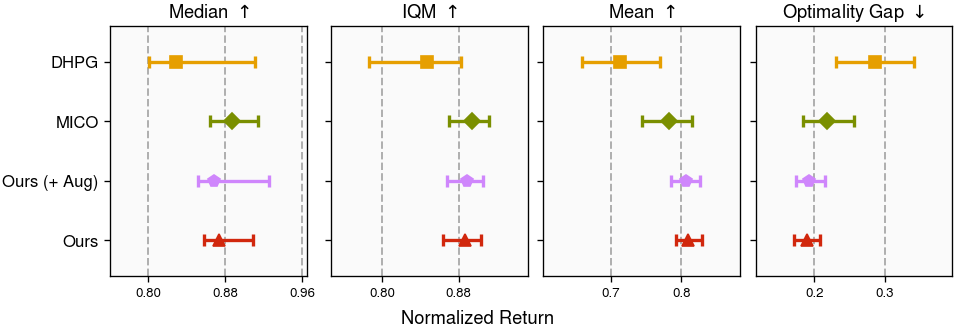

In [38]:
fig = rc.fig_aggregate_metrics(agg_scores, agg_cis, algos, labels,
                               colors, markers, args, tag)
fig.set_figheight(2.8)
fig.set_figwidth(8)

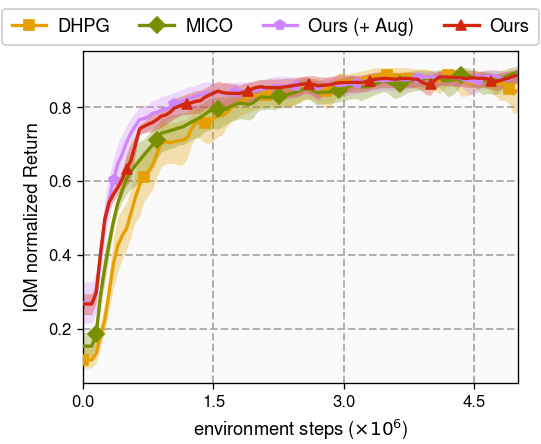

In [33]:
fig = rc.fig_sample_efficiency(frames, iqm_scores, iqm_cis, algos, labels,
                               colors, markers, args, tag)

# example of a one-off tweak that doesn't touch args:
# fig.axes[0].set_ylim(0, 1); fig.axes[0].legend(loc="lower right")
fig.set_figheight(3.8)
fig.set_figwidth(4.2)

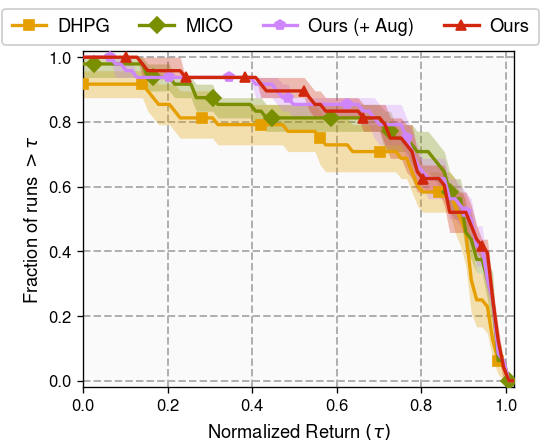

In [32]:
fig = rc.fig_performance_profile(prof, prof_cis, taus, algos, labels,
                                 colors, markers, args, tag)
fig.set_figheight(3.8)
fig.set_figwidth(4.2)

In [16]:
# fig = rc.fig_probability_of_improvement(poi_rows, labels, colors, markers, args)

### The per-environment grid

`rc.fig_grid` exposes every knob as a keyword argument, independent of `args`.
Keeping them in one `GRID` dict means the save cell in section 6 reproduces
exactly what you see here.

Sizing note: `panel_width`/`panel_height` set the *slot* each panel gets. Tick
labels and titles are drawn inside that slot, so the visible box is slightly
smaller. `extra_width`/`extra_height` are the allowances for the shared axis
labels and the legend; the final canvas is
`ncols*panel_width + extra_width` by `nrows*panel_height + extra_height`.

In [17]:
tasks

['BallInCup',
 'CartpoleBalanceSparse',
 'CartpoleSwingup',
 'CartpoleSwingupSparse',
 'CheetahRun',
 'FingerSpin',
 'FingerTurnEasy',
 'FingerTurnHard',
 'FishSwim',
 'HopperHop',
 'HopperStand',
 'ReacherEasy',
 'ReacherHard',
 'WalkerRun',
 'WalkerStand',
 'WalkerWalk']

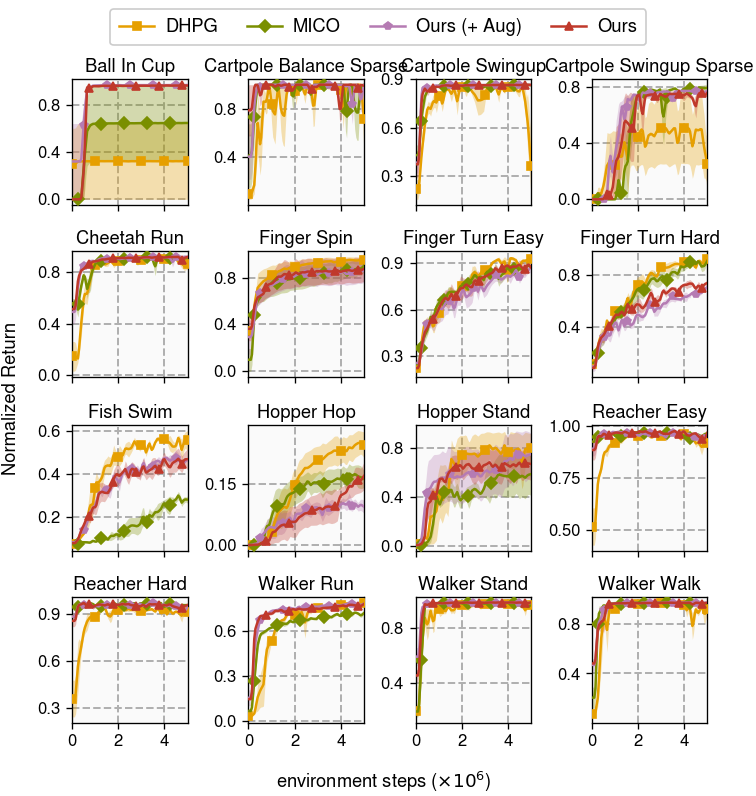

In [18]:
GRID = dict(
    # ---- which panels, and in what order -----------------------------------
    envs=tasks,              # None = all; or ["WalkerWalk", "CheetahRun", ...]
                            #   -- the list order IS the panel order
    titles=None,            # {"BallInCup": "Ball-in-Cup (sparse)"} to rename
    ncols=4,                # panels per row

    # ---- geometry, inches --------------------------------------------------
    panel_width=1.45,       # slot width per panel
    panel_height=1.45,      # slot height per panel
    extra_width=0.9,       # allowance for the shared y-label + tick labels
    extra_height=0.95,      # allowance for the x-label + legend
    w_pad=0.07,             # horizontal gap between panels
    h_pad=0.08,             # vertical gap between panels
    margin_left=0.0,
    margin_right=0.5,       # add ~0.5 to balance the y-label space on the left

    # ---- lines -------------------------------------------------------------
    line_width=1.5,
    marker_size=4.8,
    markers_per_curve=5,    # roughly how many markers each curve gets
    show_markers=True,
    band="sem",             # "sem" | "std" | "minmax" | None
    band_alpha=0.3,

    # ---- text sizes; None inherits the global style from args --------------
    title_size=None,        # per-panel titles
    tick_size=None,         # tick labels
    label_size=None,        # the shared x/y labels
    legend_size=None,

    # ---- axes --------------------------------------------------------------
    xlabel=None,            # None = "environment steps (x10^6)"
    ylabel=None,            # None = "Normalized <metric>"
    xlim=None,              # (lo, hi); None = (0, last step)
    ylim=None,              # (0, 1) for every panel, or {"CheetahRun": (0, .8)}
    xticks=3,               # approximate tick counts
    yticks=None,            # None picks 3 or 4 based on panel_width
    sharey=False,
    logx=False,

    # ---- legend ------------------------------------------------------------
    legend="above",         # "above" (framed, floating) | "inside" | None
    legend_ncol=None,       # None = one row, up to 4
    legend_loc="lower right",   # only used when legend="inside"
)

fig = rc.fig_grid(curves, frames, tasks, algos, labels, colors, markers,
                  tag=tag, **GRID)
fig.set_figwidth(6.5)

Overrides for one-off variants — pass anything on top of `GRID`:

In [24]:
labels

{'dhpg_fix2': 'DHPG',
 'mico_2': 'MICO',
 'algo_aug': 'Ours (+ Aug)',
 'algo3': 'Ours'}

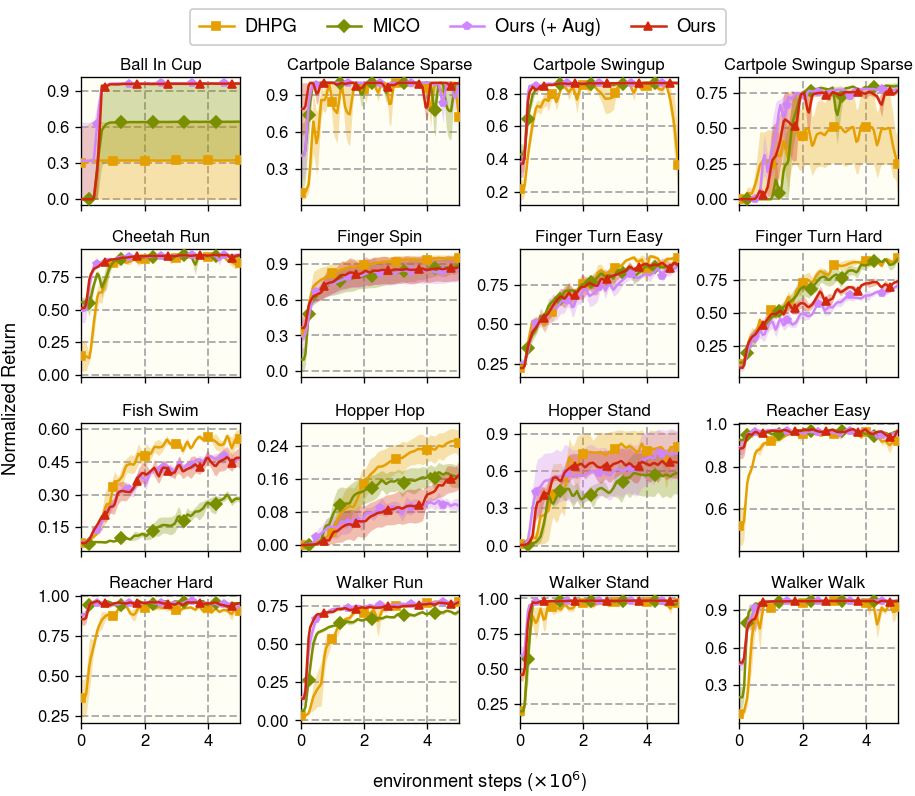

In [39]:
# a compact 3-wide figure of just the environments you want to highlight
colors["algo3"]="#d1270d"
colors["algo_aug"] = "#cf86fc"
fig = rc.fig_grid(
    curves, frames, tasks, algos, labels, colors, markers, tag=tag,
    **{**GRID,
       "envs": tasks,
       "ncols": 4,
       "panel_width": 1.8,
       "ylim": None,
       "band": "sem",
       "title_size": 10,
       "facecolor":"#fffef5",
       "legend_ncol": 4},
)

### Colour scratchpad

Preview a palette before committing it to `color_overrides`.

(np.float64(0.0), np.float64(8.0), np.float64(-0.55), np.float64(0.55))

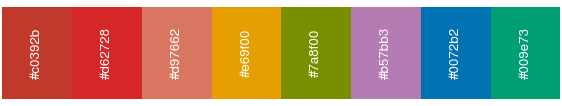

In [49]:
candidates = ["#c0392b", "#d62728", "#d97662", "#e69f00", "#7a8f00",
              "#b57bb3", "#0072b2", "#009e73"]
fig, ax = plt.subplots(figsize=(6, 1.1))
for i, hexcode in enumerate(candidates):
    ax.barh(0, 1, left=i, color=hexcode, height=1)
    ax.text(i + 0.5, 0, hexcode, ha="center", va="center",
            fontsize=8, color="white", rotation=90)
ax.set_xlim(0, len(candidates)); ax.axis("off")

## 6. Save

Writes the same filenames the CLI produces, into `args.out_dir`. Note the
figure objects above were displayed, not closed, so this re-renders them.

In [ ]:
import os
os.makedirs(args.out_dir, exist_ok=True)
written = []

written += rc.save(
    rc.fig_aggregate_metrics(agg_scores, agg_cis, algos, labels, colors,
                             markers, args, tag),
    args.out_dir, f"aggregate_metrics_{tag}", args.formats)
written += rc.save(
    rc.fig_sample_efficiency(frames, iqm_scores, iqm_cis, algos, labels,
                             colors, markers, args, tag),
    args.out_dir, f"sample_efficiency_{tag}", args.formats)
written += rc.save(
    rc.fig_performance_profile(prof, prof_cis, taus, algos, labels,
                               colors, markers, args, tag),
    args.out_dir, f"performance_profile_{tag}", args.formats)
if poi_rows:
    written += rc.save(
        rc.fig_probability_of_improvement(poi_rows, labels, colors, markers, args),
        args.out_dir, f"probability_of_improvement_{tag}", args.formats)

g = rc.fig_grid(curves, frames, tasks, algos, labels, colors, markers,
                tag=tag, **GRID)
# margins are reserved inside the figure, so don't let tight bbox crop them away
written += rc.save(g, args.out_dir, f"per_env_curves_{tag}", args.formats,
                   tight=not (GRID["margin_left"] or GRID["margin_right"]))

for path in written:
    print(path)

In [ ]:
# LaTeX table of the aggregate metrics, ready to \input
rows = [dict(algorithm=a, metric=name, point=agg_scores[a][k],
             ci_low=agg_cis[a][0, k], ci_high=agg_cis[a][1, k])
        for a in algos for k, name in enumerate(rc.AGG_NAMES)]
tex_path = os.path.join(args.out_dir, f"aggregate_metrics_{tag}.tex")
rc.write_latex_table(pd.DataFrame(rows), algos, labels, tex_path)
print(open(tex_path).read())

## 7. Everything else

To run the whole pipeline exactly as the CLI does, including all the CSV and
JSON side outputs:

```python
rc.run_analysis(final, curves, frames, tasks, args)
```

Or from a shell, with the settings you converged on here:

```bash
python rliable_compare.py --logs-dir logs_fresh --envs all --smooth 3 \
    --algos dhpg_fix2 algo3 \
    --label algo3="Ours" --label dhpg_fix2="DHPG" \
    --color algo3='#c0392b' \
    --grid-cols 4 --margin-right 0.55
```

### Knob reference

Three levels of control, from broad to narrow:

1. **`args` + `rc.setup_style(args)`** — defaults for every figure: font family
   and size, palette, line width, grid, panel background. Section 2.
2. **`GRID` / per-figure keywords** — anything about the grid figure, without
   touching the globals. Section 5.
3. **the returned `fig`** — plain matplotlib after the fact:
   `fig.axes[0].set_ylim(0, 1)`, `fig.axes[2].set_title("...")`,
   `fig.set_size_inches(7, 4)`.

| Want to change | Where |
|---|---|
| Display name | `labels`, section 2 |
| Legend / row order | `algos` — first entry is leftmost |
| A colour | `color_overrides`, section 2 |
| Panels per row | `GRID["ncols"]` |
| Size of each subplot | `GRID["panel_width"]`, `GRID["panel_height"]` |
| Gap between subplots | `GRID["w_pad"]`, `GRID["h_pad"]` |
| Which panels, and their order | `GRID["envs"]` |
| Panel titles | `GRID["titles"]` |
| Font size, whole figure | `font_size` in section 2, then re-run `setup_style` |
| Font size, one element | `GRID["title_size"]`, `["tick_size"]`, `["label_size"]`, `["legend_size"]` |
| Line thickness, marker size | `GRID["line_width"]`, `["marker_size"]` |
| Band meaning and opacity | `GRID["band"]`, `["band_alpha"]` |
| Axis ranges / tick counts | `GRID["ylim"]`, `["xlim"]`, `["yticks"]`, `["xticks"]` |
| Legend placement | `GRID["legend"]`, `["legend_ncol"]`, `["legend_loc"]` |
| Whitespace at the edges | `GRID["margin_left"]`, `["margin_right"]` |
| Defaults for the *other* figures | `rc.setup_style`, lines ~100-135 of the script |
